# Some Basic Imports

In [12]:
import os
import time
import torch
import random
import minari
import numpy as np
import pprint

from dataclasses import dataclass
from torch import nn, Tensor
from torch.utils.data import DataLoader

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver
from flow_matching.utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt
from matplotlib import cm

from src.pipelines.preprocessing import (
    collate_fn,
    get_dataset_stats,
    create_trajectory_chunks,
    create_normalized_chunks,
)
from src.pipelines.eval import (
    WrappedModel,
    WrappedConditionalModel,
    evaluate_open_loop,
    evaluate_policy_mpc,
)
from src.pipelines.sampling import generate_trajectory, unnormalize_trajectory
from src.models.backbone import MLP, CNN, ConditionalCNN
from src.utils.loggers import WandBLogger

# visualization and evaluation
from src.pipelines.lunarlander.visualizers import visualize_trajectories as hvt
from src.pipelines.hopper.visualizers import visualize_trajectory as lvt

# To avoid meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="torch")

if torch.cuda.is_available():
    device = "cuda:0"
    print("Using gpu")
else:
    device = "cpu"
    print("Using cpu.")
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

Using cpu.


# Mujoco Problems


In [ ]:
from src.pipelines.lunarlander.visualizers import visualize_dataset
from src.conf.environment import HopperConfig, Walker2dConfig

config = HopperConfig()

minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
minari_dataset_stats = get_dataset_stats(minari_dataset)
visualize_dataset(minari_dataset)
minari_dataset_stats

In [ ]:
# try replaying a random episode
from src.pipelines.hopper.visualizers import visualize_trajectory as hvt

minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
minari_dataset_stats = get_dataset_stats(minari_dataset)
long_episode = random.choice(minari_dataset.filter_episodes(lambda x: len(x.actions) > 950))
expert_obs = long_episode.observations
hvt(expert_obs, horizon=100)

In [ ]:
@dataclass
class HopperArgs:
    environment: str = "Hopper-v4"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 100
    print_every: int = 10
    lr: float = 1e-3
    hidden_dim: int = 128
    kernel_size: int = 5
    step_size: float = 0.05
    solver_method: str = "midpoint"
    inference_batch_size: int = 1
    condition_on: str = "start_obs"
    model_type: str = "ccnn"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
args = HopperArgs()

# Loading dataset
minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = (obs_dim + action_dim) * args.horizon
cond_dim = obs_dim
minari_dataset_stats = get_dataset_stats(minari_dataset)
dataloader = DataLoader(minari_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)

SAVE_DIR = "src/checkpoints"
run_name = f"{args.environment}_{args.model_type}_h{args.horizon}_e{args.num_epochs}_k{args.kernel_size}_start_obs"
MODEL_NAME = run_name + ".pth"
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
pp = pprint.PrettyPrinter(indent=2)
print("Training configuration:")
pp.pprint(config)
pp.pprint(args)
print("Run name:", run_name)

In [ ]:
# Try training with refactored code
# logger = WandBLogger(
#     config=args,
#     run_name=run_name
# )
# model, stats, input_dim = train(
#     config=config, args=args, dataset=minari_dataset, logger=logger
# )
# logger.finish()

In [ ]:
env = minari_dataset.recover_environment()
print(f"Loading model from {MODEL_SAVE_PATH}...")
state_dict = torch.load(MODEL_SAVE_PATH, map_location=device)
vf = ConditionalCNN(
    horizon=args.horizon,
    input_dim=input_dim,
    hidden_dim=args.hidden_dim,
    cond_dim=cond_dim,
    kernel_size=args.kernel_size,
).to(device)
vf.load_state_dict(state_dict)
wrapped_vf = WrappedConditionalModel(vf)
step_size = 0.05
T = torch.linspace(0, 1, 10)  # sample times
T = T.to(device=device)
solver = ODESolver(velocity_model=wrapped_vf)  # create an ODESolver class

env = minari_dataset.recover_environment()
start_observation, _ = env.reset()
start_obs_tensor = torch.from_numpy(start_observation)
obs, act = generate_trajectory(
    stats = minari_dataset_stats,
    solver = solver,
    T = T, 
    input_dim = input_dim,
    args = args,
    horizon = args.horizon,
    condition={args.condition_on: start_obs_tensor},
    batch_size = args.inference_batch_size
)
hvt(obs, horizon=args.horizon, verbose=False)
hvt(expert_obs, horizon=args.horizon, verbose=False)

In [ ]:
# evaluate the model
from src.pipelines.eval import evaluate_policy_mpc

env = minari_dataset.recover_environment(eval_env=True, render_mode="human")
num_eval_episodes = 10
mpc_planner = lambda obs: generate_trajectory(
    stats=minari_dataset_stats,
    solver=solver,
    T=T,
    input_dim=input_dim,
    args=args,
    horizon=args.horizon,
    condition={args.condition_on: obs},
    batch_size=args.inference_batch_size,
)
model_rewards = evaluate_policy_mpc(
    env, mpc_planner, num_eval_episodes, replan_freq=1, render=False, max_episode_length=1000
)
env.close()
avg_model_reward = np.mean(model_rewards)
std_model_reward = np.std(model_rewards)
print(
    f"Average MPC Reward over {num_eval_episodes} episodes: {avg_model_reward:.2f} +/- {std_model_reward:.2f}"
)

# Lunar Lander

## Some Basic Dataset Statistics


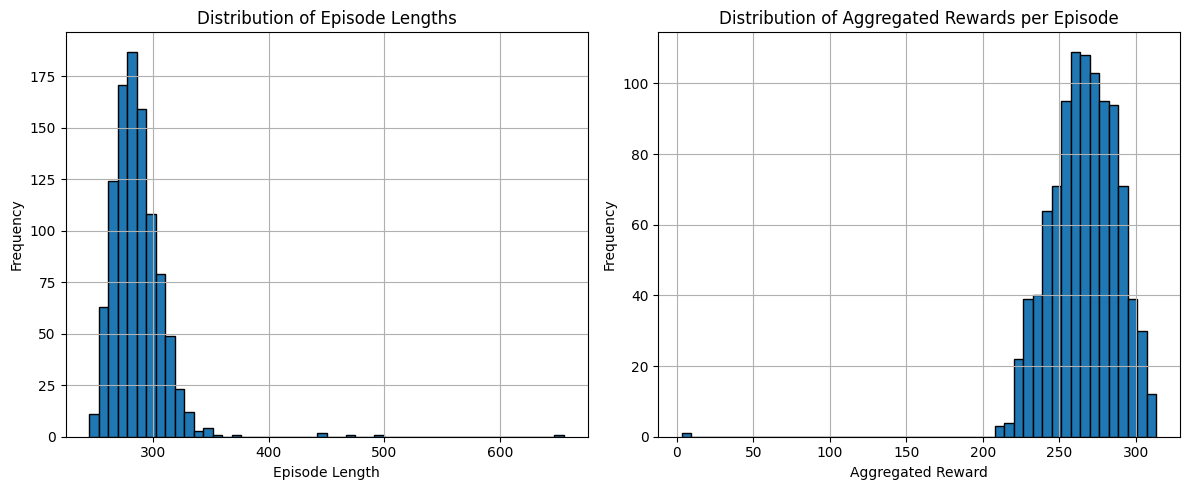

Total number of episodes: 1000
Average episode length: 286.24
Min episode length: 245
Max episode length: 655
Average aggregated reward: 265.91
Min aggregated reward: 3.29
Max aggregated reward: 313.31


{'obs_mean': tensor([-3.8224e-03,  4.5600e-01, -1.2215e-02, -2.1999e-01,  8.3548e-03,
          5.4869e-05,  1.5350e-01,  1.5069e-01]),
 'obs_std': tensor([0.1204, 0.4510, 0.1873, 0.1716, 0.1091, 0.0863, 0.3605, 0.3577]),
 'act_mean': tensor([-0.0279,  0.0534]),
 'act_std': tensor([0.5133, 0.3983]),
 'rew_mean': tensor(265.9089),
 'rew_std': tensor(22.3478)}

In [13]:
from src.pipelines.lunarlander.visualizers import visualize_dataset
from src.conf.environment import LunarLanderConfig

config = LunarLanderConfig()
minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
minari_dataset_stats = get_dataset_stats(minari_dataset)
visualize_dataset(minari_dataset)
minari_dataset_stats

## Trajectory Visualization from Expert Dataset

Visualing random chunks from each batch...


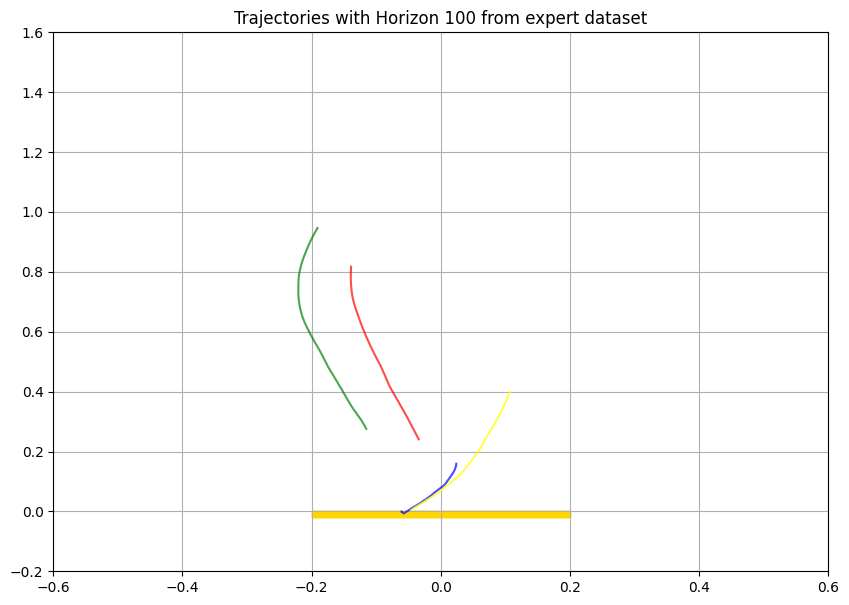

In [14]:
from src.pipelines.lunarlander.visualizers import visualize_chunk
horizon = 100
dataloader = DataLoader(minari_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title(f'Trajectories with Horizon {horizon} from expert dataset')
print("Visualing random chunks from each batch...")
colors = ['red', 'green', 'blue', 'yellow']
for idx, batch in enumerate(dataloader):
    processed_chunks = create_trajectory_chunks(batch, horizon)
    random_chunk = random.choice(processed_chunks)
    assert random_chunk.shape == (horizon * (config.obs_dim + config.action_dim),)
    random_chunk = random_chunk.reshape(horizon, config.obs_dim + config.action_dim)
    expert_obs = random_chunk[:, :config.obs_dim]
    visualize_chunk(ax, expert_obs, color=colors[idx % len(colors)], mode="line")

## Training 🏋️

### Conditional Generation on Starting Observations + Goal


In [15]:
@dataclass
class LunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 100
    print_every: int = 10
    lr: float = 1e-3
    hidden_dim: int = 128
    kernel_size: int = 5
    step_size: float = 0.05
    solver_method: str = "midpoint"
    inference_batch_size: int = 1
    condition_on: str = "start_obs_goal"
    model_type: str = "ccnn"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
args = LunarLanderArgs()

# Preparing the dataset
minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = (obs_dim + action_dim) * args.horizon
cond_dim = obs_dim * 2
minari_dataset_stats = get_dataset_stats(minari_dataset)
dataloader = DataLoader(minari_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)

SAVE_DIR = "src/checkpoints"
run_name = f"{args.environment}_{args.model_type}_h{args.horizon}_e{args.num_epochs}_k{args.kernel_size}_start_obs_goal"
MODEL_NAME = run_name + ".pth"
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
pp = pprint.PrettyPrinter(indent=2)
print("Training configuration:")
pp.pprint(config)
pp.pprint(args)
print("Run name:", run_name)

Training configuration:
LunarLanderConfig(env_name='LunarLander-v3',
                  dataset_name='LunarLanderContinuous-v3/ppo-1000-deterministic-v1',
                  obs_dim=8,
                  action_dim=2)
LunarLanderArgs(environment='LunarLander-v3',
                horizon=100,
                batch_size=32,
                num_epochs=100,
                print_every=10,
                lr=0.001,
                hidden_dim=128,
                kernel_size=5,
                step_size=0.05,
                solver_method='midpoint',
                inference_batch_size=1,
                condition_on='start_obs_goal',
                model_type='ccnn',
                device='cpu')
Run name: LunarLander-v3_ccnn_h100_e100_k5_start_obs_goal


In [5]:
# # Comment out to run on GPU
# logger = WandBLogger(
#     config=args,
#     run_name=run_name
# )
# model, stats, input_dim = train(
#     config=config, args=args, dataset=minari_dataset, logger=logger
# )
# env = minari_dataset.recover_environment()
# logger.finish()

Loaded model from src/checkpoints/LunarLander-v3_ccnn_h100_e100_k5_start_obs_goal.pth...


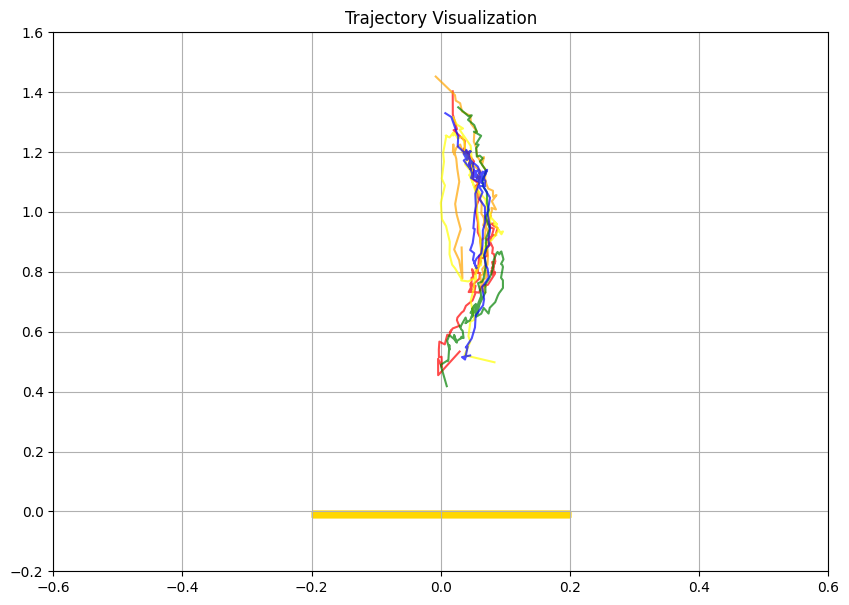

In [16]:
print(f"Loaded model from {MODEL_SAVE_PATH}...")
state_dict = torch.load(MODEL_SAVE_PATH, map_location=device)
vf = ConditionalCNN(
    horizon=horizon,
    input_dim=input_dim,
    hidden_dim=args.hidden_dim,
    cond_dim=cond_dim,
    kernel_size=args.kernel_size,
).to(device)
vf.load_state_dict(state_dict)
env = minari_dataset.recover_environment()
fig, ax = evaluate_open_loop(env, vf, minari_dataset_stats, input_dim, args)
plt.show()
plt.close(fig)

In [ ]:
num_episodes = 10
env = minari_dataset.recover_environment(eval_env=True, render_mode="human")
wrapped_vf = WrappedConditionalModel(vf)
solver = ODESolver(velocity_model=wrapped_vf)
T = torch.linspace(0, 1, 10)
final_goal_state = torch.tensor([0, 0, 0, 0, 0, 0, 1, 1], dtype=torch.float32)

mpc_planner = lambda cond_dict: generate_trajectory(
    stats=minari_dataset_stats,
    solver=solver,
    T=T,
    input_dim=input_dim,
    horizon=horizon,
    condition=cond_dict,
    batch_size=args.inference_batch_size,
)
model_rewards = evaluate_policy_mpc(
    env=env,
    planner_fn=mpc_planner,
    num_episodes=num_episodes,
    condition_type="start_obs_goal",
    goal_obs=final_goal_state,
    replan_freq=2,
    render=False,
)
env.close()
avg_model_reward = np.mean(model_rewards)
std_model_reward = np.std(model_rewards)
print(
    f"Average MPC Reward over {num_episodes} episodes: {avg_model_reward:.2f} +/- {std_model_reward:.2f}"
)


--- Starting MPC Evaluation (Condition Type: start_obs_goal) and Replan Frequency: 2 ---
Episode 1/10 finished. Total Reward: 133.29
Episode 2/10 finished. Total Reward: 138.87
Episode 3/10 finished. Total Reward: 24.08
Episode 4/10 finished. Total Reward: 1.96
Episode 5/10 finished. Total Reward: 152.87
Episode 6/10 finished. Total Reward: 146.92
Episode 7/10 finished. Total Reward: 179.30
Episode 8/10 finished. Total Reward: 189.45
Episode 9/10 finished. Total Reward: 170.27
Episode 10/10 finished. Total Reward: 162.21


NameError: name 'num_eval_episodes' is not defined

### Conditional Generation on Starting Observation

In [ ]:
# training args
@dataclass
class LunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 100
    print_every: int = 10
    lr: float = 1e-3
    hidden_dim: int = 128
    kernel_size: int = 5
    step_size: float = 0.05
    solver_method: str = "midpoint"
    inference_batch_size: int = 1
    condition_on: str = "start_obs"
    model_type: str = "ccnn"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
args = LunarLanderArgs()

In [ ]:
# Preparing the dataset
minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = (obs_dim + action_dim) * args.horizon
cond_dim = obs_dim
minari_dataset_stats = get_dataset_stats(minari_dataset)
dataloader = DataLoader(minari_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)

SAVE_DIR = "src/checkpoints"
run_name = f"{args.model_type}_h{args.horizon}_e{args.num_epochs}_k{args.kernel_size}_start_obs"
MODEL_NAME = run_name + ".pth"
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
pp = pprint.PrettyPrinter(indent=2)
print("Training configuration:")
pp.pprint(config)
pp.pprint(args)
print("Run name:", run_name)

In [ ]:
# Comment out to run on GPU
# logger = WandBLogger(
#     config=args,
#     run_name=run_name
# )
# model, stats, input_dim = train(
#     config=config, args=args, dataset=minari_dataset, logger=logger
# )
# env = minari_dataset.recover_environment()
# evaluate_open_loop(env, model, stats, input_dim, args, logger=logger)
# logger.finish()

In [ ]:
print(f"Loading model from {MODEL_SAVE_PATH}...")
state_dict = torch.load(MODEL_SAVE_PATH, map_location=device)
vf = ConditionalCNN(
    horizon=horizon,
    input_dim=input_dim,
    hidden_dim=args.hidden_dim,
    cond_dim=cond_dim,
    kernel_size=args.kernel_size,
).to(device)
vf.load_state_dict(state_dict)
wrapped_vf = WrappedConditionalModel(vf)
step_size = 0.05
T = torch.linspace(0, 1, 10)  # sample times
T = T.to(device=device)
solver = ODESolver(velocity_model=wrapped_vf)  # create an ODESolver class

env = minari_dataset.recover_environment()
start_observation, _ = env.reset()
start_obs_tensor = torch.from_numpy(start_observation)
trajectory_fn = lambda: generate_trajectory(
    stats = minari_dataset_stats,
    solver = solver,
    T = T, 
    input_dim = input_dim,
    args = args,
    horizon = horizon,
    condition={args.condition_on: start_obs_tensor},
    batch_size = args.inference_batch_size
)
visualize_trajectories(trajectory_fn)

### Model Predcitve Control Loop

In [ ]:
# let's do some MPC functionality
from src.pipelines.eval import evaluate_policy_mpc
num_eval_episodes = 10
env = minari_dataset.recover_environment(eval_env=True, render_mode="human")

mpc_planner = lambda obs: generate_trajectory(
    stats=minari_dataset_stats,
    solver=solver,
    T=T,
    input_dim=input_dim,
    args=args,
    horizon=horizon,
    condition={args.condition_on: obs},
    batch_size=args.inference_batch_size,
)
model_rewards = evaluate_policy_mpc(env, mpc_planner, num_eval_episodes, replan_freq=5)
env.close()
avg_model_reward = np.mean(model_rewards)
std_model_reward = np.std(model_rewards)
print(
    f"Average MPC Reward over {num_eval_episodes} episodes: {avg_model_reward:.2f} +/- {std_model_reward:.2f}"
)

### Conditional Generation on Rewards

In [ ]:
# Training params
horizon = 100
lr = 1e-3
num_epochs = 100
print_every = 10
hidden_dim = 256
batch_size = 32
kernel_size = 10  # For ConditionalCNN, set kernel size 

# Preparing the dataset
dataset_name = "LunarLanderContinuous-v3/ppo-1000-deterministic-v1"
minari_dataset =minari.load_dataset(dataset_id=dataset_name)
env = minari_dataset.recover_environment()
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]
input_dim = (obs_dim + action_dim) * horizon
transition_dim = obs_dim + action_dim
minari_dataset_stats = get_dataset_stats(minari_dataset)
dataloader = DataLoader(minari_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
# model_type = "CNN"
model_type = "ConditionalCNN"

# config for wandb
config = {
    "horizon": horizon,
    "action_dim": action_dim,
    "obs_dim": obs_dim,
    "kernel_size": kernel_size,
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "model_type": model_type,
    "lr": lr
}

SAVE_DIR = "src/checkpoints"
run_name = f"{model_type}_h{horizon}_e{num_epochs}_k{kernel_size}"
MODEL_NAME = run_name + ".pth"
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
pp = pprint.PrettyPrinter(indent=2)
print("Training configuration:")
pp.pprint(config)
print("Run name:", run_name)

In [ ]:
logger = WandBLogger(config = config, run_name=run_name)
# vf = MLP(input_dim=input_dim, time_dim=1, hidden_dim=hidden_dim).to(device)
# vf = CNN(horizon=horizon, transition_dim=transition_dim, hidden_dim=hidden_dim).to(device)
vf = ConditionalCNN(horizon=horizon, transition_dim=transition_dim, hidden_dim=hidden_dim, kernel_size=10).to(device)
path = AffineProbPath(scheduler=CondOTScheduler())
optim = torch.optim.Adam(vf.parameters(), lr=lr)
print("Starting training...")
for epoch in range(num_epochs):
    total_loss = 0.0
    total_chunks = 0
    start_time = time.time()

    for batch in dataloader:
        optim.zero_grad()
        
        x_1, c = create_normalized_chunks(batch, horizon, minari_dataset_stats, conditional=True)
        if x_1 is None:
            continue
        x_1 = x_1.to(device)
        c = c.to(device)
        x_0 = torch.randn_like(x_1).to(device)
        t = torch.rand(x_1.shape[0]).to(device)

        # 3. Forward pass and Loss
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
        predicted_velocity = vf(path_sample.x_t, path_sample.t, c)
        loss = torch.pow(predicted_velocity - path_sample.dx_t, 2).mean()

        # 4. Backward pass and Optimize
        loss.backward()
        optim.step()
        total_loss += loss.item()
        total_chunks += 1

    epoch_loss = total_loss / total_chunks if total_chunks > 0 else 0
    logger.log({"epoch loss": epoch_loss})
    if (epoch + 1) % print_every == 0:
        elapsed = time.time() - start_time
        print(f"| Epoch {epoch+1:6d} | {elapsed:.2f} s/epoch | Loss {epoch_loss:8.5f} ")
        start_time = time.time()
print("Training finished, saving model...")
os.makedirs(SAVE_DIR, exist_ok=True)
torch.save(vf.state_dict(), MODEL_SAVE_PATH)
logger.save_model(MODEL_SAVE_PATH)
logger.finish()

print(f"Model saved to {MODEL_SAVE_PATH}, training complete.")

### Sampling

In [ ]:
# try sampling from trained model...
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        return self.model(x, t)


class WrappedConditionalModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, c: torch.Tensor, **extras):
        return self.model(x, t, c)


print(f"Loading model from {MODEL_SAVE_PATH}...")
state_dict = torch.load(MODEL_SAVE_PATH, map_location=device)
# vf = CNN(horizon=horizon, transition_dim=transition_dim, hidden_dim=hidden_dim).to(device)
vf = ConditionalCNN(
    horizon=horizon, transition_dim=transition_dim, hidden_dim=hidden_dim, kernel_size=kernel_size
).to(device)
vf.load_state_dict(state_dict)
# wrapped_vf = WrappedModel(vf)
wrapped_vf = WrappedConditionalModel(vf)
step_size = 0.05
T = torch.linspace(0, 1, 10)  # sample times
T = T.to(device=device)
solver = ODESolver(velocity_model=wrapped_vf)  # create an ODESolver class


def generate_trajectory(stats, target_reward: float = None, batch_size=1):
    if target_reward is not None:
        # dealing with condition tensor
        rew_mean = stats["rew_mean"].to(device)
        rew_std = stats["rew_std"].to(device)
        norm_c = (torch.tensor([target_reward], device=device) - rew_mean) / rew_std
        c_tensor = norm_c.view(1, 1).expand(batch_size, -1)

        # rest should be the same as unconditional generation
        x_init = torch.randn(
            (batch_size, input_dim), dtype=torch.float32, device=device
        )

        sol = solver.sample(
            time_grid=T,
            x_init=x_init,
            c=c_tensor,
            method="midpoint",
            step_size=step_size,
            return_intermediates=True,
        )
        final_trajectory = sol[-1]
        obs, act = unnormalize_trajectory(
            final_trajectory.flatten().detach(), stats, horizon, obs_dim, action_dim
        )
        return obs, act
    else:
        x_init = torch.randn(
            (batch_size, input_dim), dtype=torch.float32, device=device
        )
        sol = solver.sample(
            time_grid=T,
            x_init=x_init,
            method="midpoint",
            step_size=step_size,
            return_intermediates=True,
        )
        final_trajectory = sol[-1]

        obs, act = unnormalize_trajectory(
            final_trajectory.flatten().detach(), stats, horizon, obs_dim, action_dim
        )
        return obs, act


# unconditional generation
# obs, act = generate_trajectory(minari_dataset_stats, batch_size=1)
# conditional generation"
target_reward = 275
obs, act = generate_trajectory(minari_dataset_stats, batch_size=1, target_reward=275)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title(f'Trajectories with horizon {horizon} and target reward {target_reward}')
# visulizing trajectories   
for _ in range(4):
    colors = ['blue', 'red', 'green', 'yellow']
    observations, actions = generate_trajectory(minari_dataset_stats, batch_size=1 , target_reward=target_reward)
    assert observations.shape == (horizon, obs_dim)
    visualize_chunk(ax, observations, color=colors[_ % len(colors)], mode='line')

### Sanity Check by Overfitting ✅
Let's do a sanity check first on one chunk of the dataset with horizon length 10.

In [ ]:
from src.utils.loggers import WandBLogger

# training parameters
horizon = 10
input_dim = (obs_dim + action_dim) * horizon
dataloader = DataLoader(
    minari_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn
)
batch = next(iter(dataloader))
normalized_chunks = create_normalized_chunks(batch, horizon, minari_dataset_stats)
expert_chunk_to_overfit = normalized_chunks[0].to(device)
assert expert_chunk_to_overfit.shape == (horizon * (obs_dim + action_dim),)

# hyperparameters
lr = 1e-4
num_epochs = 1000000
print_every = 100
hidden_dim = 256

config = {
    "horizon": horizon,
    "action_dim": action_dim,
    "obs_dim": obs_dim,
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "num_epochs": num_epochs,
    "lr": lr,
}

logger = WandBLogger(config=config)
vf = MLP(input_dim=input_dim, time_dim=1, hidden_dim=hidden_dim).to(device)
path = AffineProbPath(scheduler=CondOTScheduler())
optim = torch.optim.Adam(vf.parameters(), lr=lr)

print("Overfitting to a single chunk...")
running_loss = 0.0
for i in range(num_epochs):
    optim.zero_grad()

    x_1 = expert_chunk_to_overfit.unsqueeze(0)
    x_0 = torch.randn_like(x_1).to(device)
    t = torch.rand(x_1.shape[0]).to(device)

    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
    predicted_velocity = vf(path_sample.x_t, path_sample.t)
    loss = torch.pow(predicted_velocity - path_sample.dx_t, 2).mean()

    loss.backward()
    optim.step()

    running_loss += loss.item()
    if (i + 1) % print_every == 0:
        avg_loss = running_loss / print_every
        print(f"Iteration {i+1:6d}: Avg Loss = {avg_loss:8.5f}")
        logger.log({"avg_loss": avg_loss})
        running_loss = 0.0

### Sanity Check with Only Observations 👀

In [ ]:
def get_xy_dataset_stats(dataset):
    """Computes mean and std for ONLY the X and Y dimensions."""
    print("Calculating X,Y dataset statistics...")
    loader = DataLoader(dataset, batch_size=512, shuffle=False, collate_fn=collate_fn)
    all_obs = []
    for batch in loader:
        for i in range(batch['observations'].shape[0]):
            length = batch['episode_lengths'][i]
            all_obs.append(batch['observations'][i, :length, :2]) # Slice for only X and Y

    flat_obs = torch.cat(all_obs, dim=0)
    stats = {"xy_mean": torch.mean(flat_obs, dim=0), "xy_std": torch.std(flat_obs, dim=0)}
    stats["xy_std"][stats["xy_std"] < 1e-6] = 1e-6
    print("Statistics calculation complete.")
    return stats

def create_xy_chunks(batch, horizon, stats):
    """Creates normalized, flattened chunks of ONLY X,Y coordinates."""
    xy_mean, xy_std = stats['xy_mean'], stats['xy_std']
    all_chunks = []
    for i in range(batch['observations'].shape[0]):
        # We only need the first 2 columns (x, y) from observations
        obs_xy = batch['observations'][i, :, :2]
        length = batch['episode_lengths'][i]
        
        if length < horizon: continue
        for start_idx in range(length - horizon + 1):
            end_idx = start_idx + horizon
            xy_chunk = obs_xy[start_idx:end_idx]
            xy_chunk = xy_chunk.to(xy_mean.device)
    
            norm_xy_chunk = (xy_chunk - xy_mean) / xy_std
            all_chunks.append(norm_xy_chunk.flatten())
            
    if not all_chunks: return None
    return torch.stack(all_chunks)

def unnormalize_xy_trajectory(norm_xy_chunk, stats, horizon):
    """Un-normalizes an X,Y-only trajectory chunk."""
    xy_mean, xy_std = stats['xy_mean'], stats['xy_std']
    reshaped_chunk = norm_xy_chunk.reshape(horizon, 2) # Reshape to (horizon, 2)
    unnorm_xy = (reshaped_chunk * xy_std) + xy_mean
    return unnorm_xy

In [ ]:
# load the dataset and compute stats
batch_size = 20
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title(f'X,Y-only trajectories with Horizon {horizon}')
colors = ['red', 'green', 'blue', 'yellow']
minari_dataset = minari.load_dataset(dataset_id="LunarLanderContinuous-v3/ppo-1000-deterministic-v1")
dataset_stats = get_xy_dataset_stats(minari_dataset)
for k, v in dataset_stats.items(): dataset_stats[k] = v.to(device)
dataloader = DataLoader(minari_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
print(dataset_stats)
for idx, batch in enumerate(dataloader):
    processed_chunks = create_xy_chunks(batch, horizon, dataset_stats)
    random_chunk = random.choice(processed_chunks)
    assert random_chunk.shape == (horizon * 2,)
    random_chunk = random_chunk.reshape(horizon, 2)
    # Unnormalize the chunk for visualization
    unnorm_xy = unnormalize_xy_trajectory(random_chunk, dataset_stats, horizon)
    visualize_chunk(ax, unnorm_xy, color=colors[idx % len(colors)], mode='line', obs_dim=2)

In [ ]:
# Setup parameters
device = "cuda" if torch.cuda.is_available() else "cpu"
horizon = 100
input_dim = horizon * 2  # just the x and y dimensions
hidden_dim = 256
obs_dim = 2
action_dim = 0

# model parameters
transition_dim = obs_dim + action_dim

# training paraeters
lr = 1e-4
num_epochs = 100
print_every = 10
config = {
    "horizon": horizon,
    "obs_dim": 2,
    "action_dim": 0,
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "lr": lr,
    "num_epochs": num_epochs
}

# Initialize model and optimizer
logger = WandBLogger(config=config)
# vf = MLP(input_dim=input_dim, time_dim=1, hidden_dim=hidden_dim).to(device)
vf = CNN(horizon=horizon, transition_dim=transition_dim, hidden_dim=hidden_dim).to(device)

path = AffineProbPath(scheduler=CondOTScheduler())
optim = torch.optim.Adam(vf.parameters(), lr=lr)

print("\nStarting X,Y-only sanity check training...")
for epoch in range(num_epochs):
    total_epoch_loss = 0.0
    total_chunks = 0
    start_time = time.time()

    for batch in dataloader:
        optim.zero_grad()
    
        x_1 = create_xy_chunks(batch, horizon, dataset_stats)
        if x_1 is None: continue
        x_1 = x_1.to(device)
        x_0 = torch.randn_like(x_1).to(device)
        t = torch.rand(x_1.shape[0]).to(device)

        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
        predicted_velocity = vf(path_sample.x_t, path_sample.t)
        loss = torch.pow(predicted_velocity - path_sample.dx_t, 2).mean()

        loss.backward()
        optim.step()
        total_epoch_loss += loss.item()
        total_chunks += 1

    avg_epoch_loss = total_epoch_loss / total_chunks if total_chunks > 0 else 0
    logger.log({"avg_epoch_loss": avg_epoch_loss})
    if (epoch + 1) % print_every == 0:
        elapsed = time.time() - start_time
        print(f"| Epoch {epoch+1:6d} | {elapsed:.2f} s/epoch | Loss {avg_epoch_loss:8.5f} ")
        start_time = time.time()
print("X,Y-only sanity check training complete.")


In [ ]:
# # --- 3. Evaluation ---
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        return self.model(x, t)

wrapped_vf = WrappedModel(vf)
step_size = 0.05
batch_size = 1 
T = torch.linspace(0, 1, 10)  # sample times
T = T.to(device=device)
solver = ODESolver(velocity_model=wrapped_vf)


x_init = torch.randn((1, input_dim), dtype=torch.float32, device=device)
sol = solver.sample(x_init=x_init, T=T, step_size=step_size, batch_size=batch_size)
generated_norm_chunk = sol[-1].squeeze(0).detach()
generated_xy = unnormalize_xy_trajectory(generated_norm_chunk, dataset_stats, horizon)
generated_xy.shape


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title(f'Trajectories with horizon {horizon} and x,y')
colors = ['red', 'green', 'blue', 'yellow']

# visulizing trajectories
for _ in range(4):
    x_init = torch.randn((1, input_dim), dtype=torch.float32, device=device)
    sol = solver.sample(x_init=x_init, T=T, step_size=step_size, batch_size=batch_size)
    generated_norm_chunk = sol[-1].squeeze(0).detach()
    generated_xy = unnormalize_xy_trajectory(generated_norm_chunk, dataset_stats, horizon)
    generated_xy.shape
    assert generated_xy.shape == (horizon, 2)
    visualize_chunk(ax, generated_xy, color=colors[_ % len(colors)],
                    x_limits=(-2, 2), y_limits=(-1, 2), mode='scatter', obs_dim=2)

This shows that even if we only model x and y, our generated observations still lack spatial coherence!

## Evaluation

In [ ]:
num_episodes = 100
horizon = 100
target_rewards = [0, 50, 100, 150, 200, 250, 275, 300]

def eval_policy_open_loop(env, planner, num_episodes, horizon, verbose=False):
    rewards = []
    for eps in range(num_episodes):
        _, actions = planner()
        obs, _ = env.reset()
        total_rew = 0
        for i in range(horizon):
            action = actions[i].cpu().numpy()
            obs, rew, terminated, truncated, info = env.step(action)
            total_rew += rew
            if terminated or truncated:
                break
        rewards.append(total_rew)
        if verbose:
            print(f"Episode {eps + 1}/{num_episodes} - Total Reward: {total_rew}")
            print(f"Finished episode {eps + 1}/{num_episodes} - Model Reward: {total_rew}")
    return rewards
    
env = minari_dataset.recover_environment(eval_env=True)

for target_reward in target_rewards:
    fm_planner = lambda: generate_trajectory(minari_dataset_stats, target_reward=target_reward)
    model_rewards = eval_policy_open_loop(env, fm_planner, num_episodes, horizon)
    avg_model_rewards = np.mean(model_rewards)
    print(f"Average Model Reward (Target {target_reward}): {avg_model_rewards:.2f}")


## Our FM Planner vs. Random Planner

In [ ]:
random_planner = lambda: (None, torch.tensor(np.array([env.action_space.sample() for _ in range(horizon)]), dtype=torch.float32))
random_rewards = eval_policy_open_loop(env, random_planner, num_episodes, horizon)
fm_planner = lambda: generate_trajectory(minari_dataset_stats, target_reward=300)
model_rewards = eval_policy_open_loop(env, fm_planner, num_episodes, horizon)
avg_random_reward = np.mean(random_rewards)
avg_model_rewards = np.mean(model_rewards)

plt.figure(figsize=(12, 7))
# Use a shared range for the bins to make the comparison fair
bins = np.linspace(min(min(model_rewards), min(random_rewards)), max(max(model_rewards), max(random_rewards)), 30)

plt.hist(model_rewards, bins=bins, alpha=0.7, label=f'Conditional Flow Model (Avg: {avg_model_rewards:.2f})', color='blue')
plt.hist(random_rewards, bins=bins, alpha=0.7, label=f'Random Policy (Avg: {avg_random_reward:.2f})', color='red')

plt.title(f'Reward Distribution for first {horizon} steps over {num_episodes} Episodes', fontsize=16)

plt.xlabel("Total Reward per Episode", fontsize=12)

plt.ylabel("Frequency (Number of Episodes)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

## Rendering the Trajectory

In [ ]:

minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
minari_dataset_stats = get_dataset_stats(minari_dataset)
env = minari_dataset.recover_environment(eval_env=True, render_mode="human")

obs, _ = env.reset()
total_rew_random = 0
obs, actions = generate_trajectory(minari_dataset_stats, target_reward=300)
total_rew = 0
for i in range(horizon):
    action = actions[i].cpu().numpy()
    obs, rew, terminated, truncated, info = env.step(action)
    total_rew += rew
    if terminated or truncated:
        break
env.close()